# Projeto de Classificação de Doença Renal | BeeData

Projeto de classificação, do curso BeeData, para analisar, tratar e treinar um algoritmo de classificação que identifique a presença de doença renal crônica (CKD) com base no prontuário dos pacientes.

[Dataset no Kaggle](https://www.kaggle.com/datasets/alitaqishah/ckd-nhanes-2021-2023-staged-kidney-disease/data)

Feito por Isabela Aoki e Karoline Paiva

<hr>

## O que é CKD (Chronic Kidney Disease)?

A doença renal crônica (CKD) é a perda lenta e progressiva dos rins. Dessa forma, há o comprometimento da capacidade dos rins de filtrar sangue e regular hormônios.
- Algumas causas principais são diabetes e hipertensão arterial, obsesidade e doenças cardiovasculares.
- Diagnóstico: dosagem de creatinina no sangue e exame de urina.

Para achar a descrição das variáveis:
- [CDC NHANES 2021–2023 URL](https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?Cycle=2021-2023) - National Health and Nutrition Examination Survey the primary source for all lab, demographic, and lifestyle data in this dataset.

## 01. Import das bibliotecas e do dataset

In [ ]:
!pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Download
path = kagglehub.dataset_download("alitaqishah/ckd-nhanes-2021-2023-staged-kidney-disease")

df = pd.read_csv(os.path.join(path, "CKD_NHANES_2021_2023.csv"))
df.head()

100%|██████████| 372k/372k [00:00<00:00, 65.5MB/s]

Extracting files...


,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,...,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,...,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,...,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,...,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0
3,130381.0,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,...,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1


In [ ]:
df["ckd_present"].value_counts()

,count
ckd_present,
1,8341
0,3592


## 02. Divisão dos dados e análise inicial

Vamos dividir o dataset em conjunto de teste (20%) e de treinamento (80%) antes de começar. Dessa forma, evitamos o vazamento de dados, onde os dados do conjunto de teste vazam para o modelo durante o treinamento.

Ao analisar as primeiras linhas do conjunto de dados, já reparamos em várias linhas nulas.

In [ ]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size = 0.2, random_state = 77, stratify=df["ckd_present"])

print(f"Conjunto de dados possui dimensões: {df.shape}")
print(f"Base de treino com dimensões {df_train.shape} e base de teste {df_test.shape}")
print(f"Variáveis do conjunto de treino: {df_train.columns}")
print("--------------------------------------")

# Remoção das colunas do estágio do CKD e do ID da pessoa
x_train = df_train.drop(columns = ["participant_id","ckd_stage","ckd_present"])
y_train = df_train["ckd_present"]

x_test = df_test.drop(columns = ["participant_id","ckd_stage","ckd_present"])
y_test = df_test["ckd_present"]

print(f"\nAs primeiras linhas do conjunto de dados:")
print(df.head())
print("--------------------------------------")
print(f"\nInformações do dataset:")
print(df.info())

Conjunto de dados possui dimensões: (11933, 29)
Base de treino com dimensões (9546, 29) e base de teste (2387, 29)
Variáveis do conjunto de treino: Index(['participant_id', 'age', 'gender', 'ethnicity', 'education_level',
       'poverty_income_ratio', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic',
       'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen',
       'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid',
       'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio',
       'diabetes_diagnosed', 'insulin_use', 'diabetes_pills', 'ever_smoked',
       'current_smoker', 'egfr', 'ckd_stage', 'ckd_present'],
      dtype='object')
--------------------------------------

As primeiras linhas do conjunto de dados:
   participant_id   age  gender           ethnicity  education_level  \
0        130378.0  43.0    Male  Non-Hispanic Asian              5.0   
1        130379.0  66.0    Male  Non-Hispanic White              5.0   
2        130380.0  44.0  

### 02.1 Análise exploratória
   - Relação entre variáveis demográficas e casos de CKD

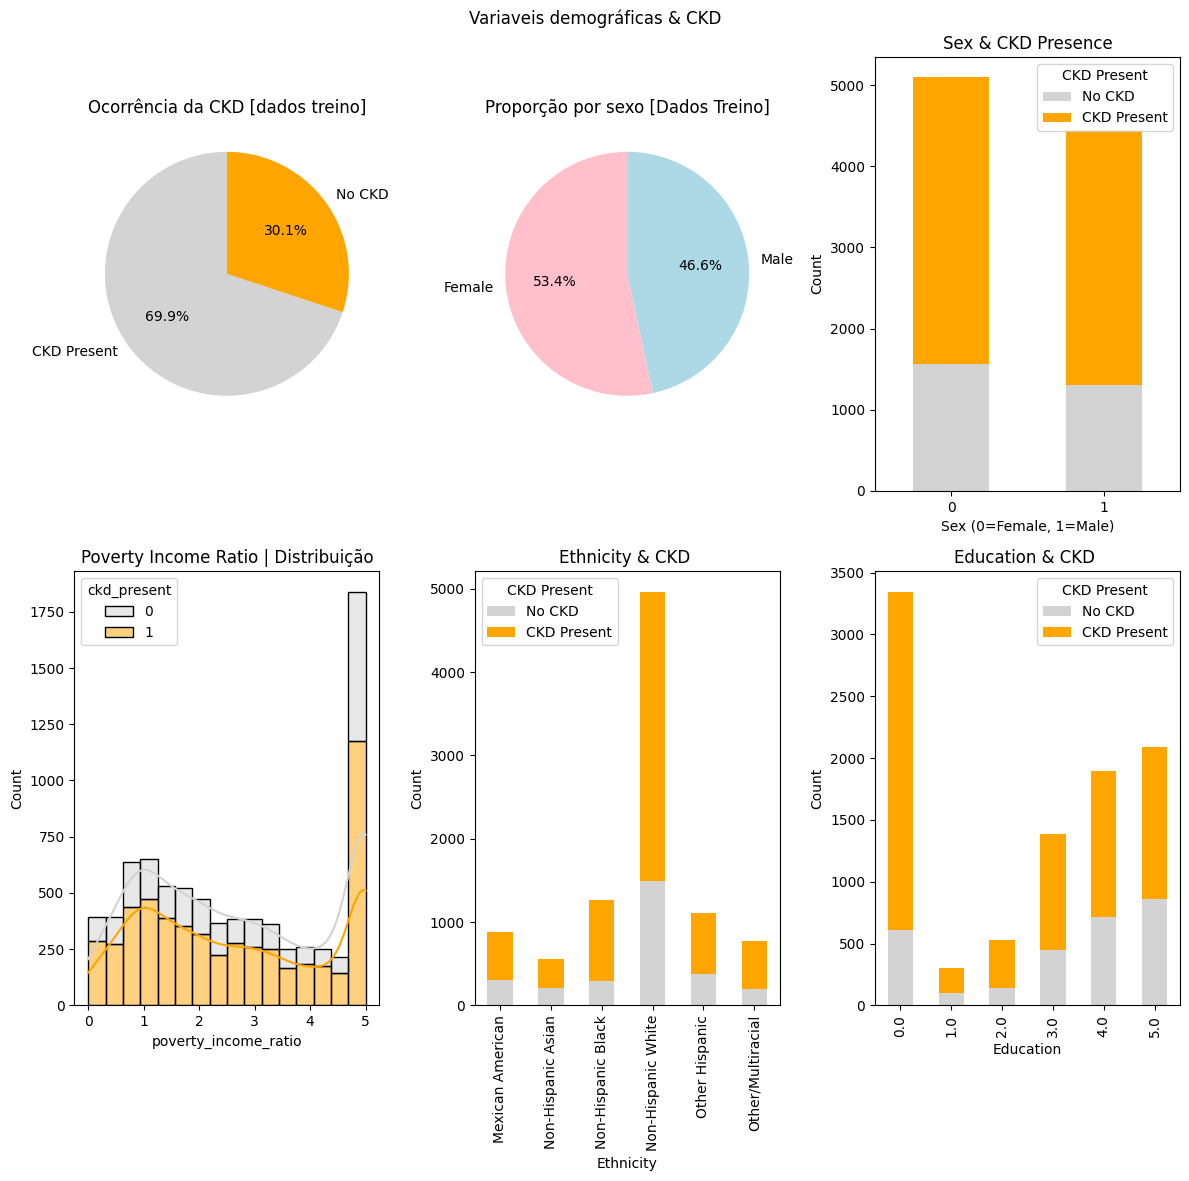

In [ ]:
# @title
# Proporção de sexo e casos de doença renal
df_train["age"] = df_train["age"].astype(int) # Converte para integer
prop_cdk = df_train.ckd_present.value_counts()

# Coluna "gender" - mapear female para 0 e male para 1
df_train["sex"] = df_train["gender"].map({
    "Female": 0,
    "Male": 1
})
prop_sex = df_train.sex.value_counts()
gender_ckd_crosstab = pd.crosstab(df_train['sex'], df_train['ckd_present'])

etn = df_train.ethnicity.value_counts()
etn_ckd_crosstab = pd.crosstab(df_train['ethnicity'], df_train['ckd_present'])

df_train.loc[df_train["education_level"] == 9, "education_level"] = np.nan
df_train["education_level"] = df_train["education_level"].fillna(0)
education_level_counts = df_train['education_level'].value_counts()

edu_crosstab = pd.crosstab(df_train['education_level'], df_train['ckd_present'])

# Ocorrencia de CDK, Sexo e Etnia
figure, axes_prop = plt.subplots(2,3, figsize=(12, 12)) # 2 rows, 3 columns
figure.suptitle('Variaveis demográficas & CKD', fontsize=12)

# Proporção de CDK : todos conjunto de treino
axes_prop[0,0].pie(prop_cdk, labels=['CKD Present', 'No CKD'], autopct='%1.1f%%', startangle=90, colors=['lightgrey', 'orange'])
axes_prop[0,0].set_title('Ocorrência da CKD [dados treino]')

# Proporção de sexo (genero)
axes_prop[0,1].pie(prop_sex, labels=['Female','Male'], autopct='%1.1f%%', startangle=90, colors=['pink', 'lightblue'])
axes_prop[0,1].set_title('Proporção por sexo [Dados Treino]')

# Empilhamento para sexo e CKD
gender_ckd_crosstab.plot(kind='bar', stacked=True, ax=axes_prop[0,2], color=['lightgrey', 'orange'])
axes_prop[0,2].set_title('Sex & CKD Presence')
axes_prop[0,2].set_xlabel('Sex (0=Female, 1=Male)')
axes_prop[0,2].set_ylabel('Count')
axes_prop[0,2].tick_params(axis='x', rotation=0)
axes_prop[0,2].legend(title='CKD Present', labels=['No CKD', 'CKD Present'])


# Empilhamento para etnia e ckd
etn_ckd_crosstab.plot(kind='bar', stacked=True,  ax=axes_prop[1,1],color=['lightgrey', 'orange'])
axes_prop[1,1].set_title('Ethnicity & CKD ')
axes_prop[1,1].set_xlabel('Ethnicity')
axes_prop[1,1].set_ylabel('Count')
#axes_prop[1,1].tick_params(axis='x', rotation=45, ha='right')
axes_prop[1,1].legend(title='CKD Present', labels=['No CKD', 'CKD Present'])

# Empilhamento para escolaridade e CKD
edu_crosstab.plot(kind='bar', stacked=True,  ax=axes_prop[1,2],color=['lightgrey', 'orange'])
axes_prop[1,2].set_title('Education & CKD ')
axes_prop[1,2].set_xlabel('Education')
axes_prop[1,2].set_ylabel('Count')
#axes_prop[1,1].tick_params(axis='x', rotation=45, ha='right')
axes_prop[1,2].legend(title='CKD Present', labels=['No CKD', 'CKD Present'])

#Histograma renda
sns.histplot(
    data=df_train,
    x='poverty_income_ratio',
    hue='ckd_present',
    multiple='stack',
    palette={0: 'lightgrey', 1: 'orange'},
    kde=True,
    edgecolor='black',
    ax=axes_prop[1,0]
)
axes_prop[1,0].set_title('Poverty Income Ratio | Distribuição')

plt.tight_layout()
plt.show()

### 02.1 Análise exploratória
   - Relação entre egfr e casos de CKD
>  **EGFR (Estimated Glomerular Filtration Rate)**: é o principal exame laboratorial para avaliar o funcionamento dos rins. A estimativa é calculada a partir de exames de sangue, utilizando equações que cruzam os níveis de creatinina (e/ou cistatina C) com a idade e o sexo do paciente.



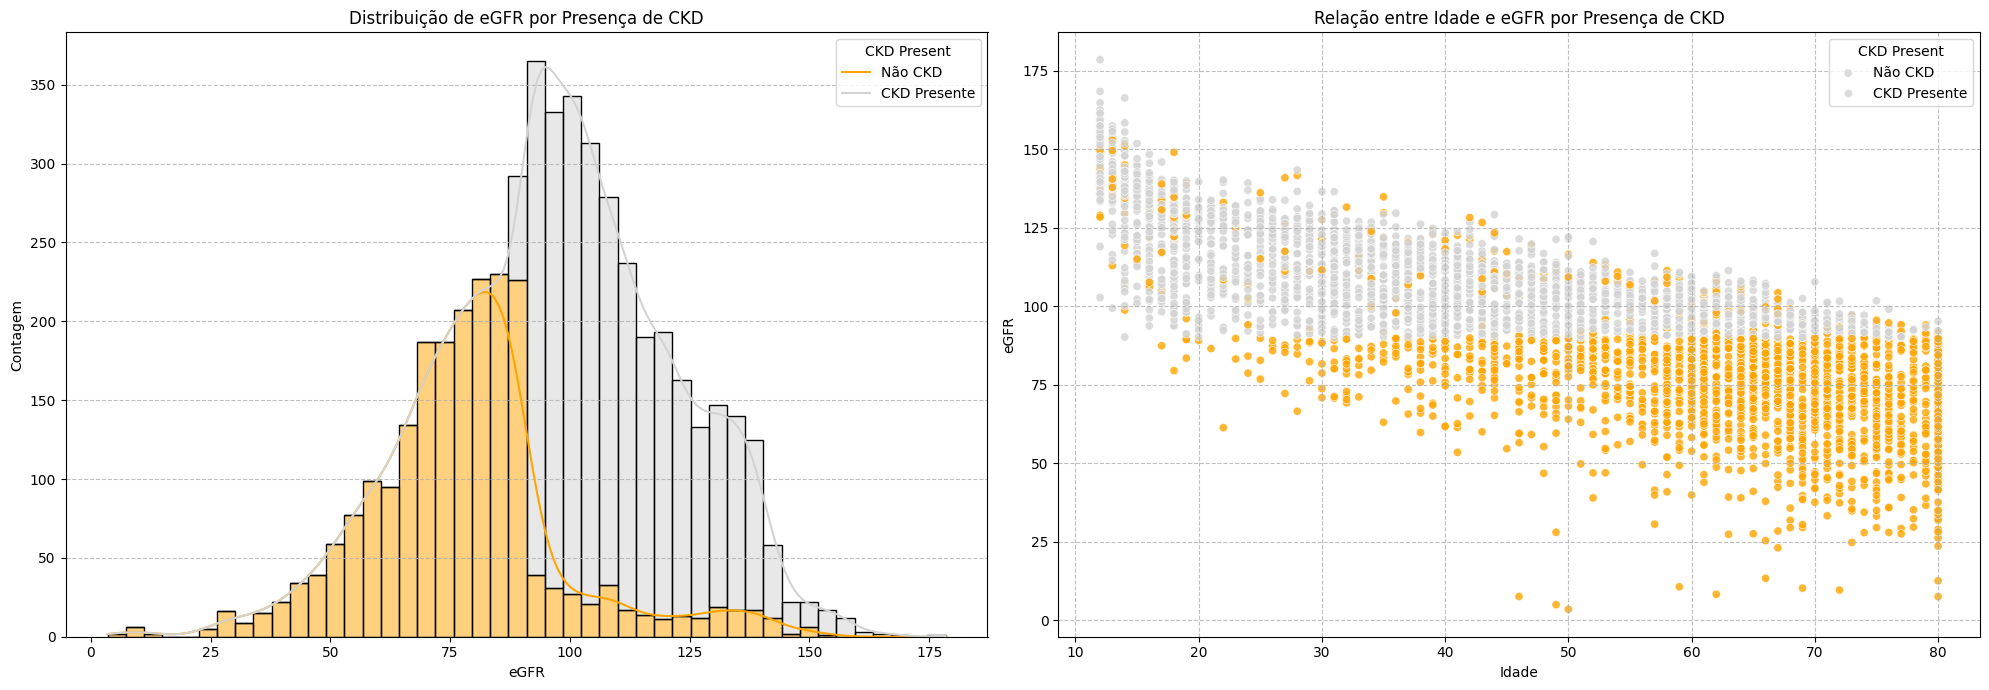

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(20, 7)) # subplots: 1 linha; 2 colunas

# Subplot 1: Histograma para variável eGFR
sns.histplot(
    data=df_train,
    x='egfr',
    hue='ckd_present',
    multiple='stack',
    palette={0: 'lightgrey', 1: 'orange'},
    kde=True,
    edgecolor='black',
    ax=axes[0]
)
axes[0].set_title('Distribuição de eGFR por Presença de CKD')
axes[0].set_xlabel('eGFR')
axes[0].set_ylabel('Contagem')
axes[0].grid(axis='y', linestyle='--', alpha=0.8)
axes[0].legend(title='CKD Present', labels=['Não CKD', 'CKD Presente'])

# Subplot 2: Scatter plot for Age vs eGFR
sns.scatterplot(
    data=df_train,
    x='age',
    y='egfr',
    hue='ckd_present',
    palette={0: 'lightgrey', 1: 'orange'},
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title('Relação entre Idade e eGFR por Presença de CKD')
axes[1].set_xlabel('Idade')
axes[1].set_ylabel('eGFR')
axes[1].grid(True, linestyle='--', alpha=0.8)
axes[1].legend(title='CKD Present', labels=['Não CKD', 'CKD Presente'])

plt.tight_layout()
plt.show()

## 03. Limpeza e Normalização dos dados

### 03.1. Análise da quantidade de dados nulos

In [ ]:
# Verificação da proporção de dados nulos para cada variável
total_rows = len(df_train)

# Verificando dados nulos para as variaveis demográficas
variaves_demograficas = ['age','gender','ethnicity','education_level','poverty_income_ratio']
null_counts_demo = df_train[variaves_demograficas].isnull().sum()
null_proportions_demo = round((null_counts_demo / total_rows), 2) * 100

null_info_demo = pd.DataFrame({
    'Count': null_counts_demo,
    '(%)': null_proportions_demo
})

print('Dados nulos para as variáveis demográficas')
print(null_info_demo)
print("--------------------------------------")

# Verificando dados nulos para as variaveis de estilo de vida
variaveis_estilo_vida = ['diabetes_diagnosed', 'insulin_use', 'diabetes_pills', 'ever_smoked']
null_count_life = df_train[variaveis_estilo_vida].isnull().sum()
null_proportion_life = round((null_count_life / total_rows), 2) * 100

null_info_life = pd.DataFrame({
    'Count': null_count_life,
    '(%)': null_proportion_life
})

print('Dados nulos para as variáveis de estilo de vida')
print(null_info_life)
print("--------------------------------------")

# Verificando dados nulos para as variaveis clinicas
variaveis_clinicas =['bmi', 'weight_kg', 'height_cm', 'bp_systolic',
       'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen',
       'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid',
       'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio']

null_count_clinic = df_train[variaveis_clinicas].isnull().sum()
null_proportion_clinic = round((null_count_clinic / total_rows), 2) * 100

null_info_clinic = pd.DataFrame({
    'Count': null_count_clinic,
    '(%)': null_proportion_clinic
})

print('Dados nulos para as variáveis clínicas')
print(null_info_clinic)
print("--------------------------------------")

# Verificando dados nulos para as variaveis classificadoras e egfr
variaveis_outras = ['egfr', 'ckd_stage', 'ckd_present']
null_count_other = df_train[variaveis_outras].isnull().sum()
null_proportion_other = round((null_count_other / total_rows),2) * 100

null_info_other = pd.DataFrame({
    'Count': null_count_other,
    '(%)': null_proportion_other
})

print('Dados nulos para as variáveis classificadoras e egfr')
print(null_info_other)

Dados nulos para as variáveis demográficas
                      Count   (%)
age                       0   0.0
gender                    0   0.0
ethnicity                 0   0.0
education_level           0   0.0
poverty_income_ratio   1632  17.0
--------------------------------------
Dados nulos para as variáveis de estilo de vida
                    Count   (%)
diabetes_diagnosed    151   2.0
insulin_use          8682  91.0
diabetes_pills       7727  81.0
ever_smoked          3060  32.0
--------------------------------------
Dados nulos para as variáveis clínicas
                          Count   (%)
bmi                        2791  29.0
weight_kg                  2562  27.0
height_cm                  2769  29.0
bp_systolic                3571  37.0
bp_diastolic               3571  37.0
serum_creatinine           4503  47.0
blood_urea_nitrogen        4503  47.0
albumin_serum              4473  47.0
phosphorus                 4509  47.0
bicarbonate                4504  47.0
calcium   

### 03.2. Limpeza do dataset

In [ ]:
# Coluna "age" - há alguns valores que não são inteiros, vamos arredondar ela
print(f"Na coluna 'age', há {(x_train["age"] % 1 != 0).sum() + (x_test["age"] % 1 != 0).sum()} valores que não são inteiros")
x_train["age"] = x_train["age"].astype(int)
x_test["age"] = x_test["age"].astype(int)

# 1. Variáveis categóricas: usualmente convertemos categorias para números (uso em algoritmos como KNN, Regressão Logística)
# Coluna "gender" - mapear female para 0 e male para 1
x_train["gender"] = x_train["gender"].map({
    "Female": 0,
    "Male": 1
})

x_test["gender"] = x_test["gender"].map({
    "Female": 0,
    "Male": 1
})

# Coluna "ethnicity" - não tem uma ordem natural, logo vamos usar one-hot encoding, criando colunas para indicar a etnia da pessoa com 1 ou 0
x_train = pd.get_dummies(x_train, columns=["ethnicity"])
x_test = pd.get_dummies(x_test, columns=["ethnicity"])
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

print(f"\nNa coluna 'ethnicity', há {df["ethnicity"].isnull().sum()} valores nulos")
print(df["ethnicity"].value_counts())

# Coluna "education_level" - há valores nulos
# Pesquisando, encontramos que os níveis de educação coletados são: "Less than 9th grade",
# "9-11th grade (Includes 12th grade with no diploma)", "High school graduate/GED or equivalent",
# "Some college or AA degree", "College graduate or above"

print(f"\nNa coluna 'education_level', há {df["education_level"].isnull().sum()} valores nulos")
print(df["education_level"].value_counts())

# Vamos manter a ordem e preencher NaN para valores iguais a 9 (respostas nulas)
x_train.loc[x_train["education_level"] == 9, "education_level"] = np.nan
x_test.loc[x_test["education_level"] == 9, "education_level"] = np.nan
x_train["education_level"] = x_train["education_level"].fillna(0)
x_test["education_level"] = x_test["education_level"].fillna(0)

Na coluna 'age', há 189 valores que não são inteiros

Na coluna 'ethnicity', há 0 valores nulos
ethnicity
Non-Hispanic White    6217
Non-Hispanic Black    1597
Other Hispanic        1373
Mexican American      1117
Other/Multiracial      948
Non-Hispanic Asian     681
Name: count, dtype: int64

Na coluna 'education_level', há 4139 valores nulos
education_level
5.0    2625
4.0    2370
3.0    1749
2.0     666
1.0     373
9.0      11
Name: count, dtype: int64


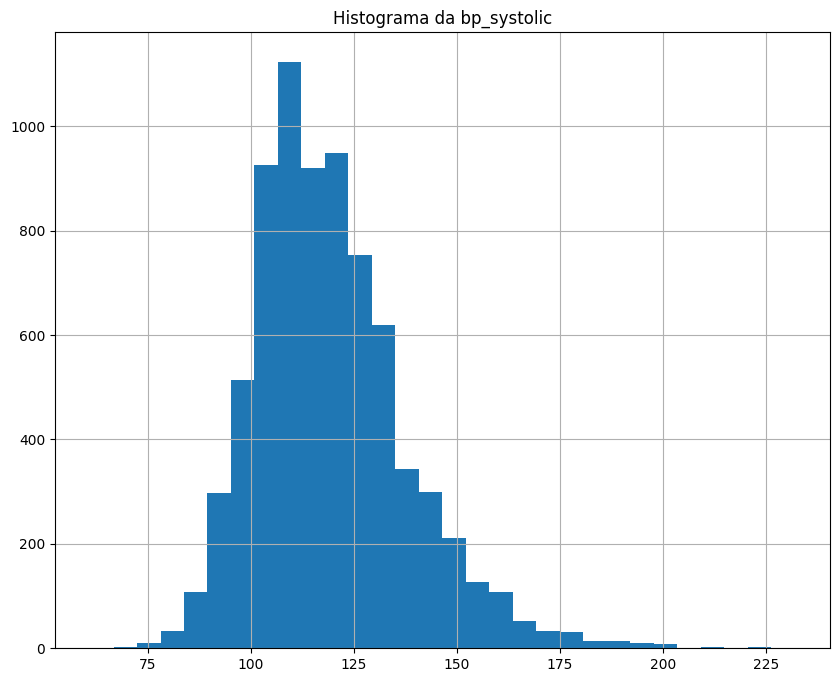

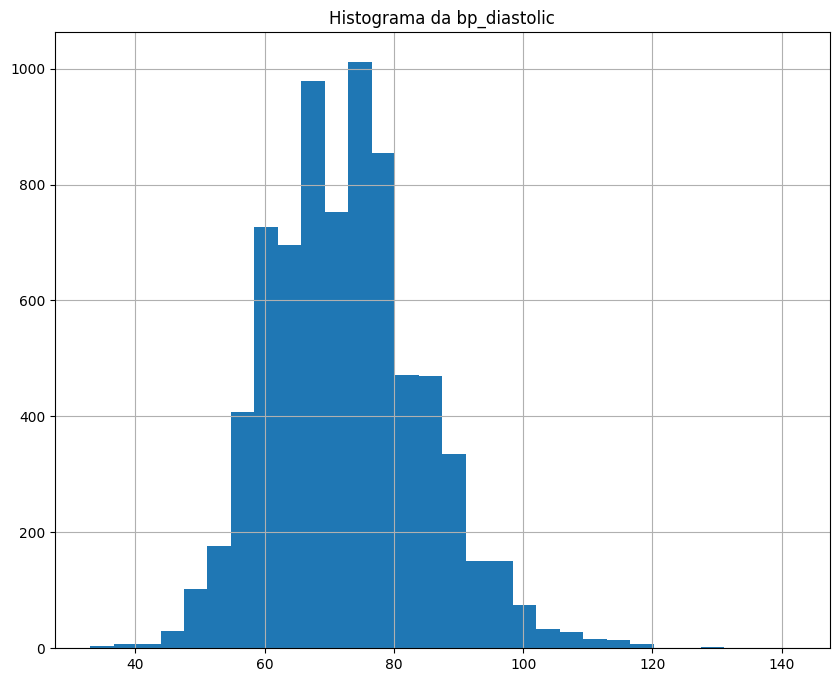

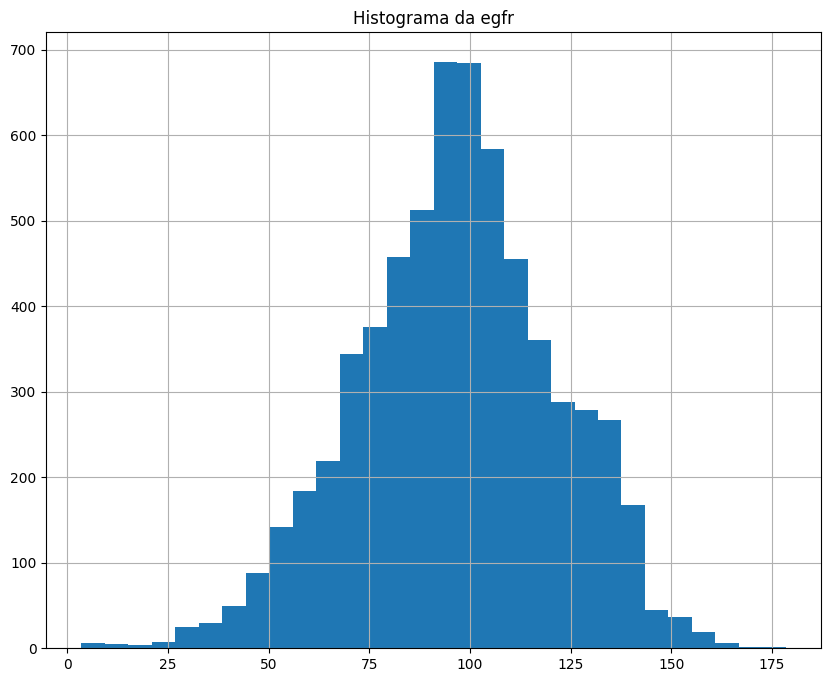

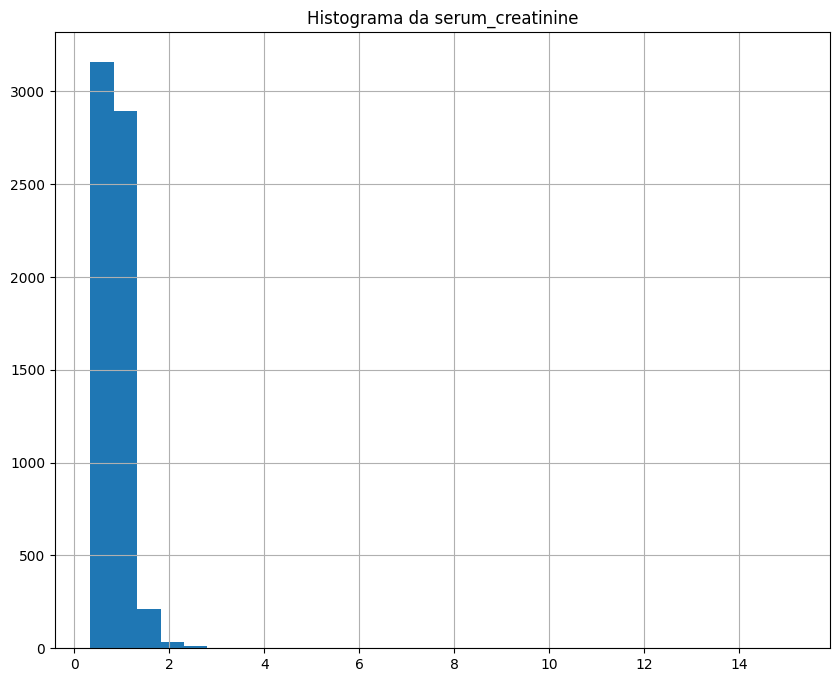

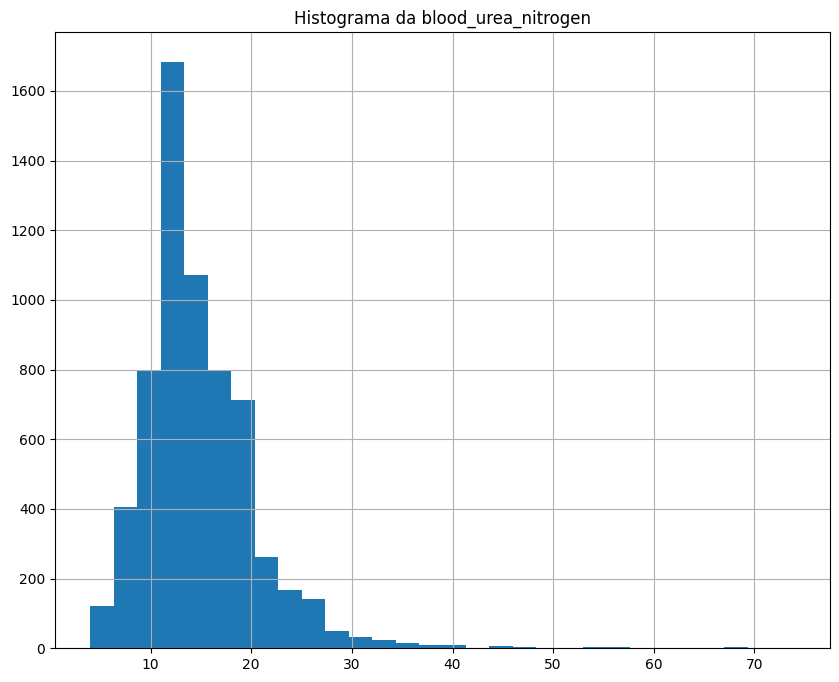

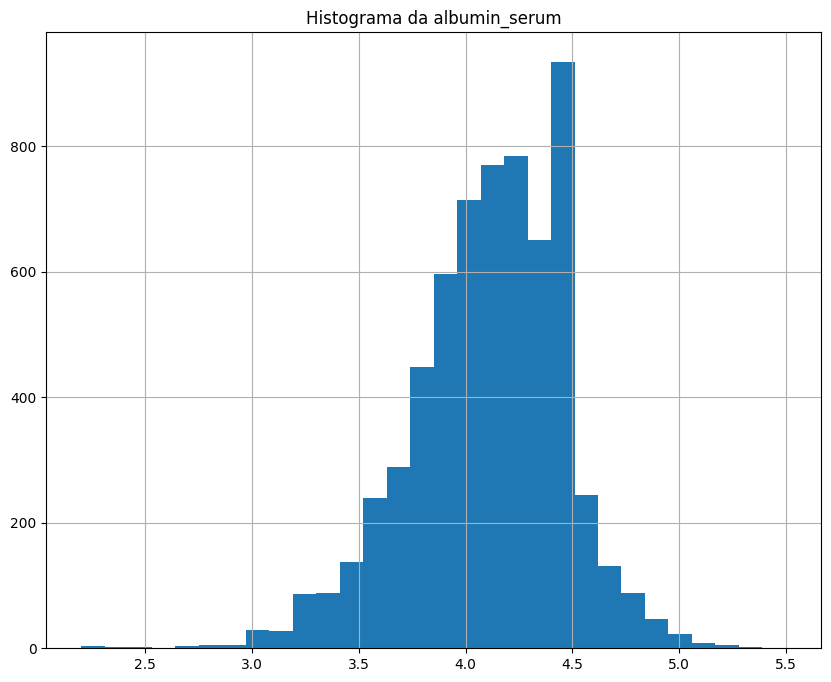

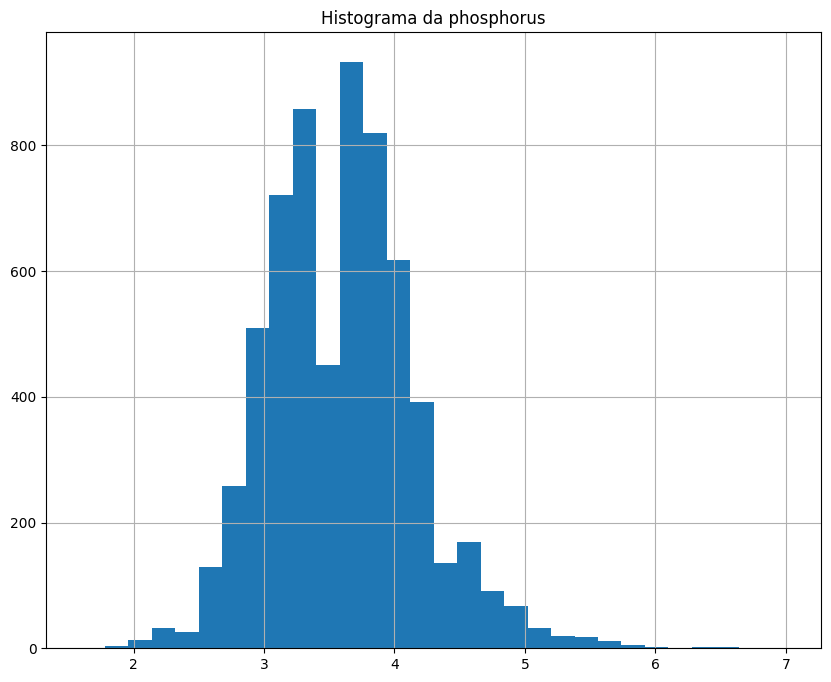

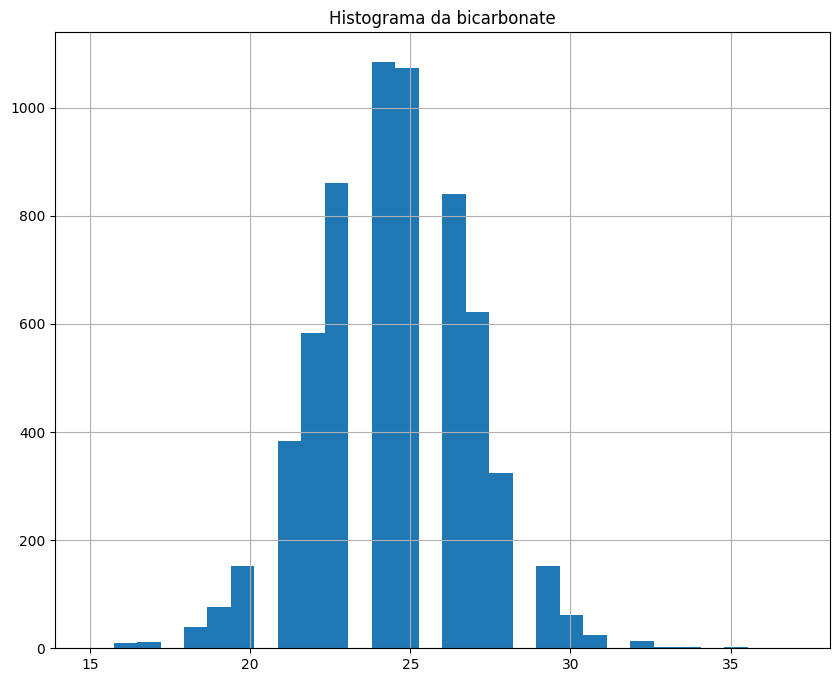

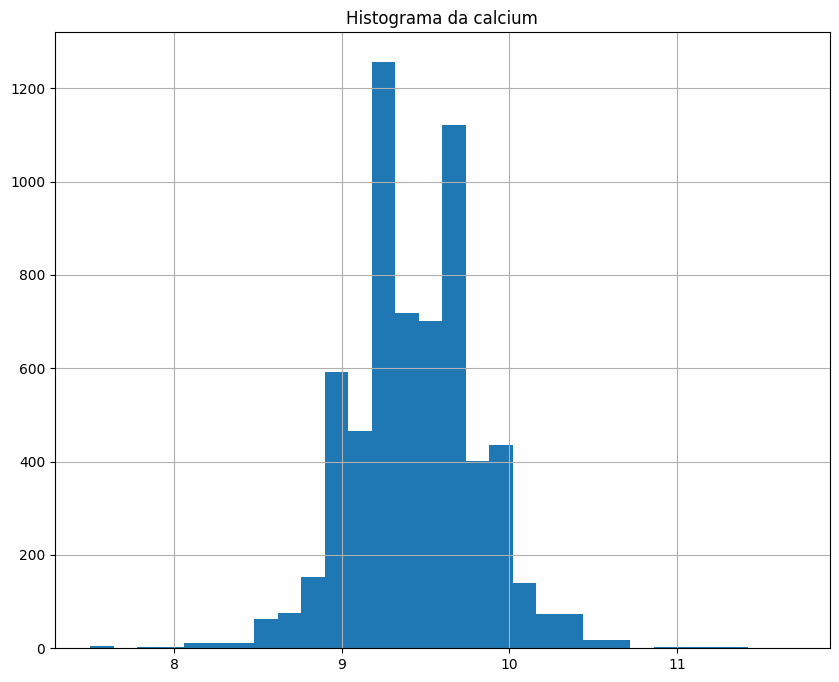

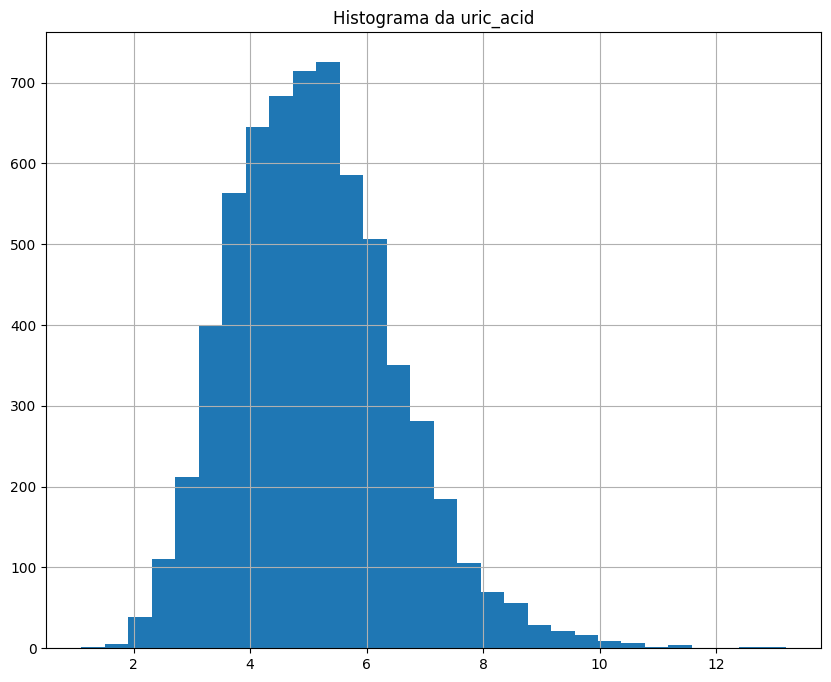

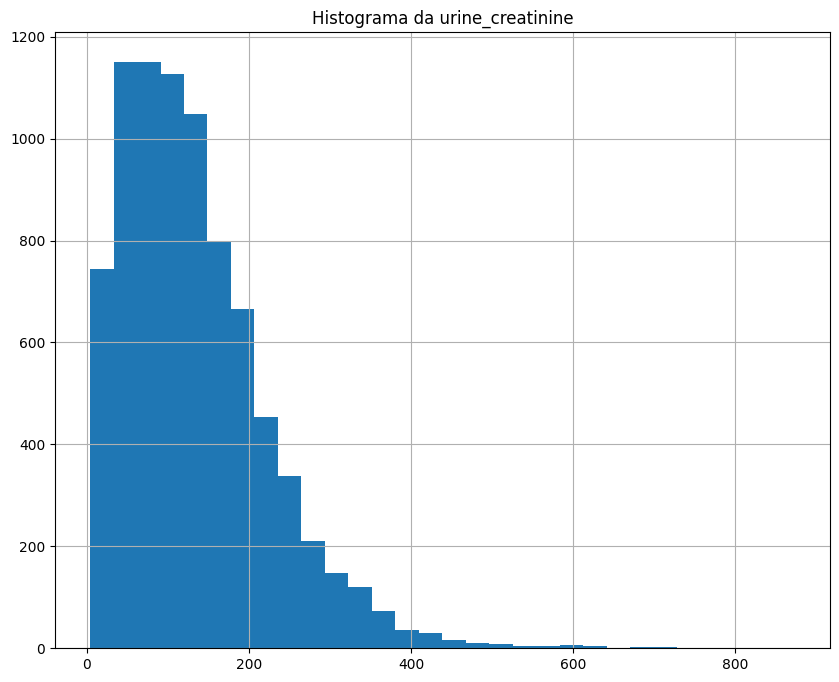

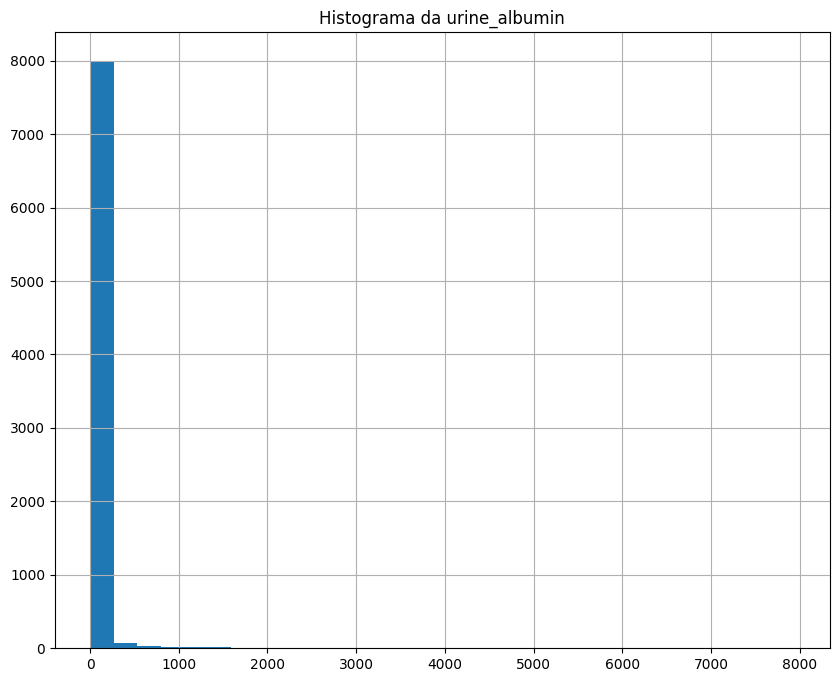

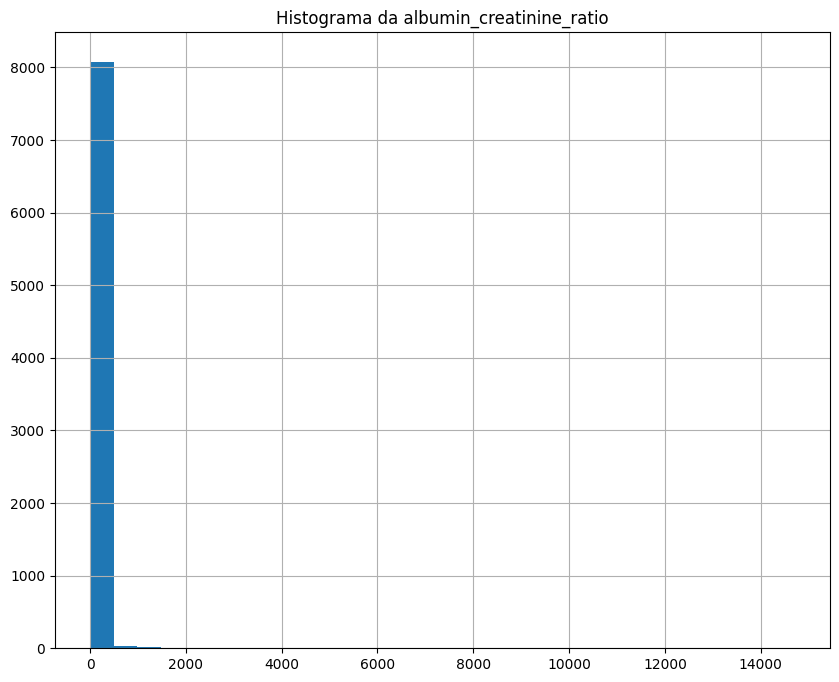

In [ ]:
# 2. Variáveis numéricas: lidar com valores nulos
# Colunas "poverty_income_ratio", "bmi", "weight", "height", "poverty_income_ratio"
# Preencher com as medianas
cols = ["poverty_income_ratio", "weight_kg", "height_cm"]
for col in cols:
  median = x_train[col].median()
  x_train[col] = x_train[col].fillna(median)
  x_test[col] = x_test[col].fillna(median)

x_train["bmi"] = x_train["bmi"].fillna(x_train["weight_kg"] / (x_train["height_cm"] / 100) ** 2)
x_test["bmi"] = x_test["bmi"].fillna(x_test["weight_kg"] / (x_test["height_cm"] / 100) ** 2)

# Colunas 'bp_systolic' e 'bp_diastolic'
# Como são valores que tem uma distribuição próxima da normal, vamos usar a média
cols = ["bp_systolic", "bp_diastolic"]
for col in cols:
  df[col].hist(bins=30, figsize=(10, 8))
  plt.title(f"Histograma da {col}")
  plt.show()

  mean = x_train[col].mean()
  x_train[col] = x_train[col].fillna(mean)
  x_test[col] = x_test[col].fillna(mean)

# Colunas de exames clínicos
# Vamos subtituir com a mediana para preservar distribuições
cols = ["egfr", "serum_creatinine", "blood_urea_nitrogen", "albumin_serum", "phosphorus", "bicarbonate", "calcium", "uric_acid", "urine_creatinine", "urine_albumin", "albumin_creatinine_ratio"]
for col in cols:
  df[col].hist(bins=30, figsize=(10, 8))
  plt.title(f"Histograma da {col}")
  plt.show()

  median = x_train[col].median()
  x_train[col] = x_train[col].fillna(median)
  x_test[col] = x_test[col].fillna(median)

In [ ]:
# Colunas sobre diabetes - lidar com valores nulos
# Os valores representam respectivamente: 1 = Yes; 2 = No; 3 = Borderline; 9 - Don't know
# Vamos substituir por don't know (que vai ser 0)
x_train["diabetes_diagnosed"] = x_train["diabetes_diagnosed"].fillna(9)
x_test["diabetes_diagnosed"] = x_test["diabetes_diagnosed"].fillna(9)
x_train.loc[x_train["diabetes_diagnosed"] == 9, "diabetes_diagnosed"] = 0
x_test.loc[x_test["diabetes_diagnosed"] == 9, "diabetes_diagnosed"] = 0

# Sobre a coluna "diabetes_pills" e "insulin_use", temos muitos valores nulos e a informação da diabetes já parece suficiente!
# Então vamos removê-las
print(f"Na coluna 'diabetes_pills', temos {df["diabetes_pills"].isnull().sum()} valores nulos, o que é {df["diabetes_pills"].isnull().sum()/len(df) * 100}%")
print(f"Na coluna 'insulin_use', temos {df["insulin_use"].isnull().sum()} valores nulos, o que é {df["insulin_use"].isnull().sum()/len(df) * 100}%")
x_train = x_train.drop("diabetes_pills", axis=1)
x_test = x_test.drop("diabetes_pills", axis=1)
x_train = x_train.drop("insulin_use", axis=1)
x_test = x_test.drop("insulin_use", axis=1)

# Colunas sobre fumar - lidar com os valores nulos
# Coluna "ever_smoked" significa se a pessoa fumou pelo menos 100 cigarros e as respostas: 1 = Yes; 2 = No; 7 = Refused; 9 = Don't know
# Vamos trocar os valores faltantes, iguais a 7 ou 9 por 0
x_train["ever_smoked"] = x_train["ever_smoked"].fillna(0)
x_test["ever_smoked"] = x_test["ever_smoked"].fillna(0)
x_train.loc[x_train["ever_smoked"] == 7, "ever_smoked"] = 0
x_test.loc[x_test["ever_smoked"] == 7, "ever_smoked"] = 0
x_train.loc[x_train["ever_smoked"] == 9, "ever_smoked"] = 0
x_test.loc[x_test["ever_smoked"] == 9, "ever_smoked"] = 0

# Sobre a coluna "current_smoker", que significa a frequência que a pessoa fuma, temos muitos valores nulos e a informação que temos já parece suficiente!
# Então vamos removê-las
print(f"Na coluna 'current_smoker', temos {df["current_smoker"].isnull().sum()} valores nulos, o que é {df["current_smoker"].isnull().sum()/len(df) * 100}%")
x_train = x_train.drop("current_smoker", axis=1)
x_test = x_test.drop("current_smoker", axis=1)

Na coluna 'diabetes_pills', temos 9652 valores nulos, o que é 80.88494092013744%
Na coluna 'insulin_use', temos 10852 valores nulos, o que é 90.941087739881%
Na coluna 'current_smoker', temos 8690 valores nulos, o que é 72.82326321964301%


In [ ]:
# Ao final da limpeza, temos o seguinte dataset
x_train.info()
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9546 entries, 340 to 6877
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           9546 non-null   int64  
 1   gender                        9546 non-null   int64  
 2   education_level               9546 non-null   float64
 3   poverty_income_ratio          9546 non-null   float64
 4   bmi                           9546 non-null   float64
 5   weight_kg                     9546 non-null   float64
 6   height_cm                     9546 non-null   float64
 7   bp_systolic                   9546 non-null   float64
 8   bp_diastolic                  9546 non-null   float64
 9   serum_creatinine              9546 non-null   float64
 10  blood_urea_nitrogen           9546 non-null   float64
 11  albumin_serum                 9546 non-null   float64
 12  phosphorus                    9546 non-null   float64
 13  bicarb

## 04. Teste com Algoritmos

Para escolhermos o algoritmo com a melhor performance, precisamos considerar algumas métricas. Além disso, nosso objetivo é que haja uma boa classificação correta de pacientes que tenham a doença (classe 1).
- **Acurácia**: mede a proporção de predições corretas entre todas as predições.
- **Precisão**: mede a quantidade de predições positivas que estão corretas.
- **Recall**: mede quantos casos positivos (classe 1) foram identificados corretamente pelo modelo.
- **F1-Score**: mede o equlíbrio entre precisão e recall de um modelo.

Assim, para o nosso caso, vamos utilizar, principalmente, o Recall, já que é importante considerar casos em que há falsos negativos (pessoas que foram classificadas como saudáveis, mas estão doentes).

### 04.1. Regressão Logística

Regressão Logística é um algoritmo de regressão linear, onde o nosso target é uma variável categórica.


[Regressão Logística](https://www.datacamp.com/tutorial/understanding-logistic-regression-python)

Accuracy: 0.8382907415165479
First predictions: [0 1 1 1 1]
Actual target values: [0, 1, 1, 1, 1]

Classification report:
               precision    recall  f1-score   support

           0       0.69      0.84      0.76       719
           1       0.92      0.84      0.88      1668

    accuracy                           0.84      2387
   macro avg       0.81      0.84      0.82      2387
weighted avg       0.85      0.84      0.84      2387



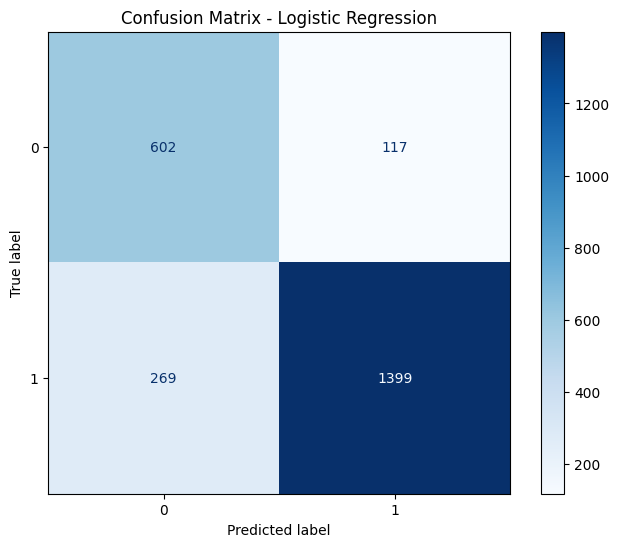

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

# Normaliza as variáveis numéricas
scaler = StandardScaler()

X_train_scaled = x_train.copy()
X_test_scaled = x_test.copy()

numeric_cols = X_train_scaled.select_dtypes(include=['float64', 'int64']).columns.tolist()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_scaled[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test_scaled[numeric_cols])

# Treinamento do modelo
logreg = LogisticRegression(class_weight='balanced', random_state=42)
logreg.fit(X_train_scaled, y_train)

# Prediçoes do modelo
y_pred = logreg.predict(X_test_scaled)
print("Accuracy:", logreg.score(X_test_scaled, y_test))

print("First predictions:", logreg.predict(X_test_scaled.head()))
print("Actual target values:", y_test.head().tolist())

print("\nClassification report:\n", classification_report(y_test, y_pred))
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(logreg, X_test_scaled, y_test, cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### 04.2. Random Forest

As árvores aletórias usam de várias árvores de decisão, criadas a partir de características aleatórias e combinando seus resultados para obter previsões melhores.

[Sobre o Random Forest](https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/)


Accuracy: 0.9987431922915794
First predictions: [0 1 1 1 1]
Actual target values: [0, 1, 1, 1, 1]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       719
           1       1.00      1.00      1.00      1668

    accuracy                           1.00      2387
   macro avg       1.00      1.00      1.00      2387
weighted avg       1.00      1.00      1.00      2387



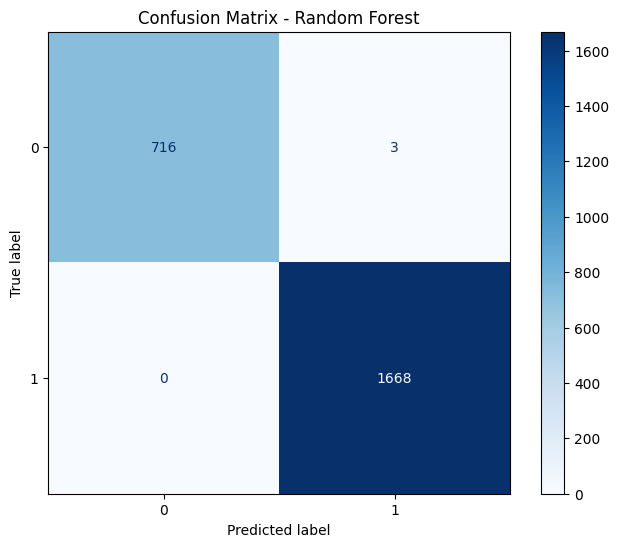

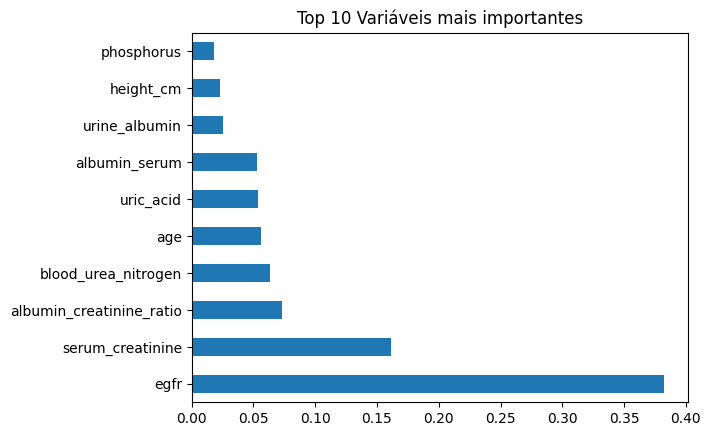

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Treinamento do modelo
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(x_train, y_train)

# Previsões do modelo
y_pred = rf.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("First predictions:", rf.predict(x_test.head()))
print("Actual target values:", y_test.head().tolist())

print("\nClassification report:\n", classification_report(y_test, y_pred))
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf, x_test, y_test, cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Random Forest')
plt.show()

importances = pd.Series(rf.feature_importances_, index=x_train.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Variáveis mais importantes")
plt.show()

Número de estimadores no Random Forest: 100


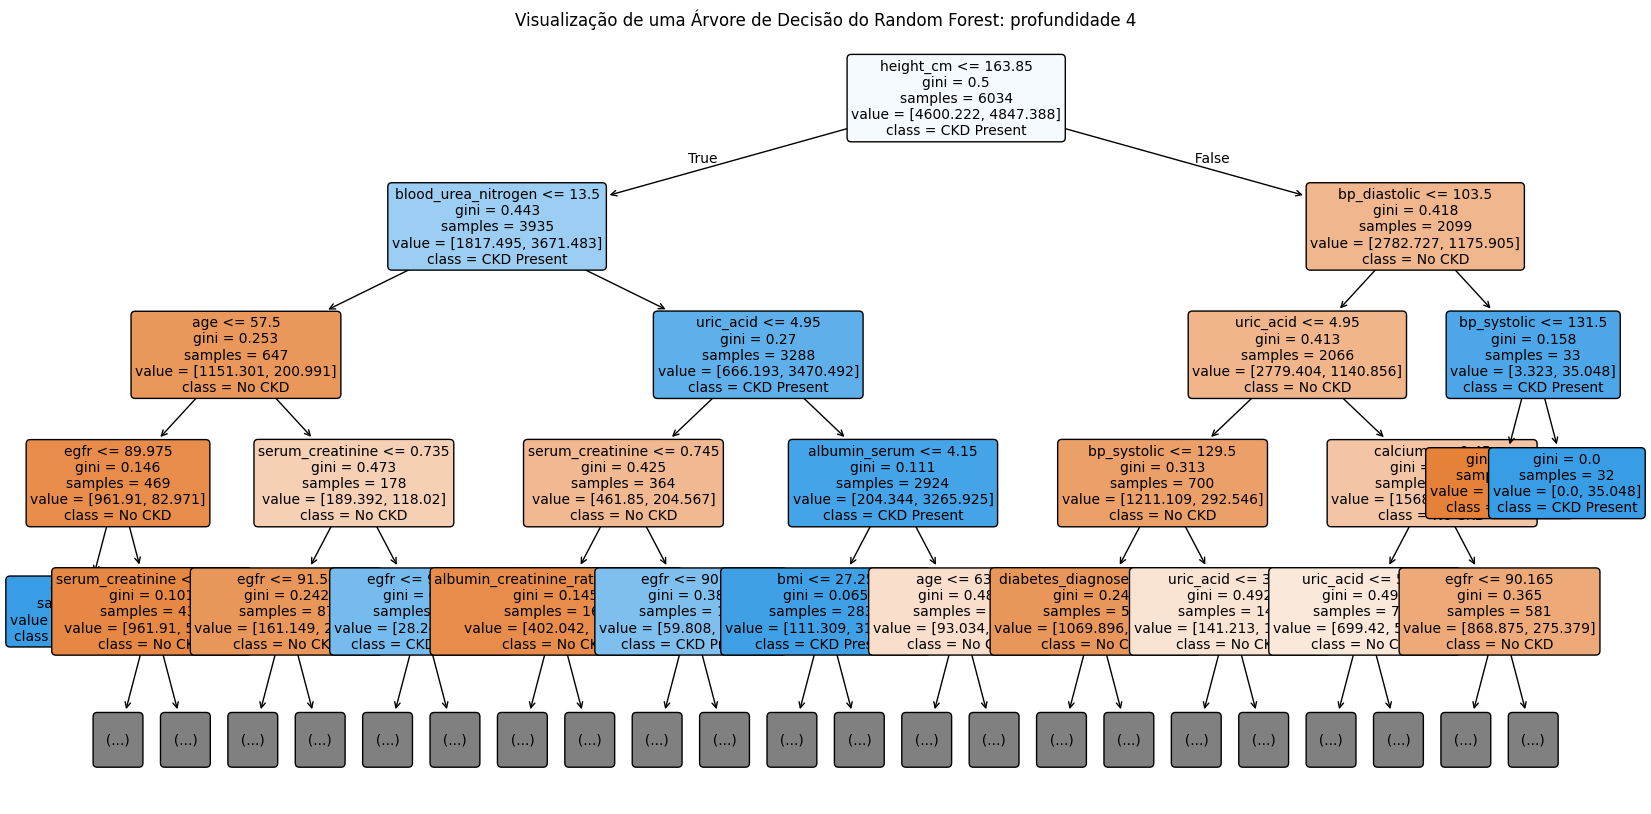

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# O Random Forest é composto por vários estimadores (árvores individuais).
# Vamos extrair a primeira árvore da floresta (índice 0) para visualizar.
tree_to_plot = rf.estimators_[0]

print(f"Número de estimadores no Random Forest: {len(rf.estimators_)}")

plt.figure(figsize=(20, 10))
plot_tree(tree_to_plot,
          feature_names=x_train.columns,
          class_names=['No CKD', 'CKD Present'],
          filled=True,
          rounded=True,
          max_depth=4, #
          fontsize=10)

plt.title("Visualização de uma Árvore de Decisão do Random Forest: profundidade 4")
plt.show()

### 04.3 KNN
O KNN é um classificador que usa a proximidade para fazer classificações ou previsões sobre o agrupamento de um determinado ponto de dados.

Com ele, realizamos mais explorações, usando GridSearch e Validação Cruzada.

[Sobre o KNN](https://www.ibm.com/br-pt/think/topics/knn)

Melhores parametros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'uniform'}

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.67      0.76       719
           1       0.87      0.96      0.91      1668

    accuracy                           0.87      2387
   macro avg       0.87      0.81      0.84      2387
weighted avg       0.87      0.87      0.87      2387



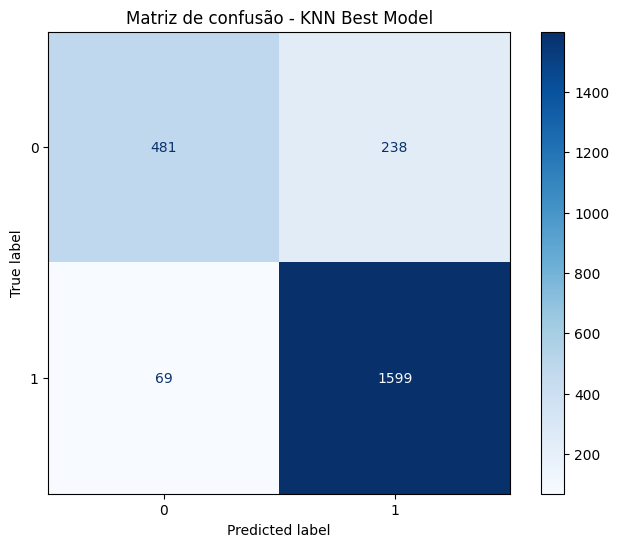

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# pipeline para normalização dos dados e aplicação knn
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Definição dos paramentros para GridSearch
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# Executa GridSearch com validação cruzada (Cross-Validation)
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='recall', n_jobs=-1) #5 folds, métrica de avaliação: recall; #n_jobs=-1 para reduzir o tempo de treino (argumento para controle de CPUs utilizados: -1 = todos disponíveis)

grid_search.fit(x_train, y_train)

print(f"Melhores parametros: {grid_search.best_params_}")

# Avalia o melhor modelo no conjunto de teste e aplica ao conjunto de teste
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)

# Print metrics | relatório completo de metricas
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_model, x_test, y_test, cmap='Blues', ax=ax)
plt.title( 'Matriz de confusão - KNN Best Model')
plt.show()

In [ ]:
# @title
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# função para resumo de métricas
def get_metrics(model, X, y_true):
    y_pred = model.predict(X)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    acc = accuracy_score(y_true, y_pred)
    return [acc, precision, recall, f1]

# reune métricas dos 3 modelos
metrics_data = {
    'Logistic Regression': get_metrics(logreg, X_test_scaled, y_test),
    'Random Forest': get_metrics(rf, x_test, y_test),
    'KNN (Best Model)': get_metrics(best_model, x_test, y_test)
}

# Cria um df pra exibir os dados
comparison_df = pd.DataFrame(
    metrics_data,
    index=['Acurácia', 'Precisão (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)']
)

# Exibe tabela comparativa
print("Tabela comparativa - métricas dos modelos:")
display(comparison_df)

Tabela comparativa - métricas dos modelos:


,Logistic Regression,Random Forest,KNN (Best Model)
Acurácia,0.838291,0.998743,0.871387
Precisão (Class 1),0.922823,0.998205,0.870441
Recall (Class 1),0.838729,1.000000,0.958633
F1-Score (Class 1),0.878769,0.999102,0.912411


## 5. Conclusão

Nesse projeto, testamos diversos modelos de classificação para identificar a presença de doença renal crônica (CKD) a partir de dados clínicos e demográficos do NHANES 2021–2023.

Dado o contexto médico do problema, priorizamos o recall como métrica principal, pois é fundamental minimizar falsos negativos. Assim, nosso objetivo é evitar classificar como saudável um paciente que, na realidade, possui CKD.

Testamos três algoritmos: Regressão Logística, Random Forest e o KNN. O algoritmo que apresentou um melhor desempenho foi o Random Forest, identificando corretamente 99% dos pacientes com CKD. O KNN, com os hiperparâmetros otimizados pelo GridSearch, também apresentou resultados bons!

Para futuras explorações, seria interessante fazer uma análise mais profunda dos dados e talvez até um preenchimento dos dados faltantes de forma condicional, levando em consideração fatores como a idade dos pacientes, o sexo, etc. Além disso, seria interessante testar outros algoritmos.